<a href="https://colab.research.google.com/github/s006aj/DATA-SCIENCE-/blob/main/Statistics_assignment_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING LIBRARIES

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

IMPORTING DATA

In [14]:
data_url ='https://drive.google.com/uc?export=download&id=1VX-LFyvlpQf7T_6lMnco0DKn6-5PtA1q'
df= pd.read_csv(data_url)
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
1,1002,Female,South,NaN,Electronics,Yes,B
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A


PREPROCESSING

In [15]:
df = df.dropna(subset=['PurchaseAmount'])
df.head()

,CustomerID,Gender,Region,PurchaseAmount,ProductCategory,Churn,CampaignGroup
0,1001,Male,South,256.07,Fashion,No,A
2,1003,Female,West,1194.41,Fashion,No,A
3,1004,Female,South,413.06,Grocery,No,A
4,1005,Male,West,1556.32,Fashion,Yes,A
5,1006,Male,North,964.44,Fashion,Yes,A


MEAN MEDIAN AND MODE

In [16]:
 mean= df['PurchaseAmount'].mean()
 median=df['PurchaseAmount'].median()
 mode=df['PurchaseAmount'].mode()
 print(mean)
 print(median)
 print(mode)

1003.9506701030928
998.0799999999999
0    0.0
Name: PurchaseAmount, dtype: float64


OUTLIER DETECTION

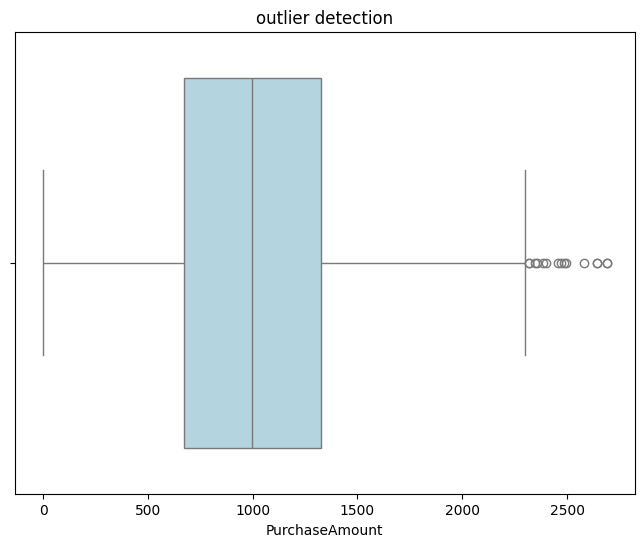

In [17]:
plt.figure(figsize=(8,6))
sns.boxplot(x=df['PurchaseAmount'], color='lightblue')
plt.title('outlier detection')
plt.show()

SKEWNESS AND KURTOSIS

In [18]:
skewness=df['PurchaseAmount'].skew()
kurtosis=df['PurchaseAmount'].kurtosis()
print(skewness)
print(kurtosis)

0.10609189374631554
-0.2615105545319705


DIFFERENCE IN SPENDING BETWEEN MALE AND FEMALE

In [19]:
male_spending = df[df['Gender'] == 'Male']['PurchaseAmount']
female_spending = df[df['Gender'] == 'Female']['PurchaseAmount']
t_stat, p_val_t = stats.ttest_ind(male_spending, female_spending, equal_var=False)
print(f"t-statistic: {t_stat:.4f}, p-value: {p_val_t:.4f}")

t-statistic: 2.2348, p-value: 0.0255


RELATIONSHIP BETWEEN PRODUCT CATEGORY AND CUSTOMER CHURN

In [20]:
contingency_table = pd.crosstab(df['ProductCategory'], df['Churn'])
print(contingency_table)
chi2, p_val_chi2, dof, expected = stats.chi2_contingency(contingency_table)
print(f"Chi-Square Statistic: {chi2:.4f}, p-value: {p_val_chi2:.4f}")

Churn             No  Yes
ProductCategory          
Electronics      762  526
Fashion          811  587
Grocery          832  584
Chi-Square Statistic: 0.3800, p-value: 0.8270


PURCHASE AMOUNT VARIATION IN DIFFERENT REGION

In [21]:
regions = df['Region'].unique()
region_groups = [df[df['Region'] == r]['PurchaseAmount'] for r in regions]

f_stat, p_val_anova = stats.f_oneway(*region_groups)
print(f"ANOVA F-statistic: {f_stat:.4f}, p-value: {p_val_anova:.4f}")

ANOVA F-statistic: nan, p-value: nan


/tmp/ipykernel_1948/2116400821.py:4: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  f_stat, p_val_anova = stats.f_oneway(*region_groups)


EMAIL CAMPAIGN PERFOMANCE

In [22]:
campaign_stats = df.groupby('CampaignGroup')['PurchaseAmount'].mean()
print("\nAverage Purchase Amount by Campaign:")
print(campaign_stats)


Average Purchase Amount by Campaign:
CampaignGroup
A    1011.945587
B     994.339965
Name: PurchaseAmount, dtype: float64


Email campaign A performed well

PURCHASE AMOUNT FOLLOWS ANORMAL DISTRIBUTION

In [23]:
shapiro_stat, p_val_norm = stats.shapiro(df['PurchaseAmount'])
print(f"Normality Test p-value: {p_val_norm:.4f}")

Normality Test p-value: 0.0000


In [ ]:
since the p value is 0 ,the purchase amount doesnot follows a normal distribution

CENTRAL LIMIT THEOREM

The Central Limit Theorem states that as long as your sample size  is sufficiently large the distribution of the sample means will automatically form a clean, symmetric normal distribution curve regardless of how skewed or nonnormal the original raw data is.

By appliying Central limit Theorem, we can safely proceed with our non normal data.Our sample size is very much larger the sampling distribution of mean become normal.

95% CONFIDANCE INTERVAL

In [25]:
sample_mean = df['PurchaseAmount'].mean()
sample_sem = stats.sem(df['PurchaseAmount'])
confidance_interval = stats.t.interval(0.95,df=len(df)-1,loc=sample_mean,scale=sample_sem)
print(f'95% confidance interval:{confidance_interval}')

95% confidance interval:(np.float64(990.3789594609216), np.float64(1017.522380745264))
